
u PCD iron contamination measurements. first i want to get a feel of what data looks like

In [16]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")

data_dir = Path(".")
assert data_dir.exists(), data_dir


In [17]:
date_re = re.compile(r"Date:\s*([0-9/]+)\s+([0-9]{1,2}):([0-9]{2})")
num_re = re.compile(r"[-+]?(?:\d+\.\d+|\d+)")


def parse_datetime(lines):
    for line in lines:
        m = date_re.search(line)
        if m:
            date_str, hh, mm = m.groups()
            try:
                return pd.to_datetime(f"{date_str} {hh}:{mm}")
            except Exception:
                return None
    return None


def parse_summary(lines):
    summary = {}
    for key in ("Average", "Median", "Deviation", "Minimum", "Maximum"):
        for line in lines[:40]:
            if line.startswith(f"{key}:"):
                m = num_re.search(line)
                summary[key.lower() + "_us"] = float(m.group(0)) if m else None
                break
    return summary



In [ ]:
pos_re = re.compile(r"Position #(\d+):\s*X=([-\d\.]+) mm, Y=([-\d\.]+) mm")


def is_map_file(path, lines):
    if "MAP" in path.name.upper():
        return True
    return any("Raster:" in ln for ln in lines[:30])


def parse_map_slx(path, lines):
    dt = parse_datetime(lines)
    summary = parse_summary(lines)
    # find data start
    try:
        data_start = next(i for i, l in enumerate(lines) if l.strip().startswith("Data:")) + 1
    except StopIteration:
        data_start = len(lines)
    rows = []
    for line in lines[data_start:]:
        if not line.strip():
            continue
        parts = line.split()
        if len(parts) != 3:
            continue
        try:
            x, y, lt = map(float, parts)
            rows.append({"x_mm": x, "y_mm": y, "lifetime_us": lt})
        except ValueError:
            continue
    df = pd.DataFrame(rows)
    return {
        "type": "map",
        "file": path.name,
        "datetime": dt,
        **summary,
        "map_points": df,
    }


def parse_point_slx(path, lines):
    dt = parse_datetime(lines)
    summary = parse_summary(lines)
    points = []
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        m = pos_re.match(line)
        if not m:
            i += 1
            continue
        idx = int(m.group(1))
        x = float(m.group(2))
        y = float(m.group(3))
        def extract_val(j, prefix):
            if j < len(lines) and lines[j].startswith(prefix):
                m = num_re.search(lines[j])
                return float(m.group(0)) if m else None
            return None
        amp = extract_val(i + 1, "Amplitude")
        lt_sl = extract_val(i + 2, "LT(Sl/1024)")
        lt_1e = extract_val(i + 3, "LT(1/e)")
        lt_1e2 = extract_val(i + 4, "LT(1/e2)")
        start_us = extract_val(i + 5, "StartTime")
        offset = extract_val(i + 6, "Offset")
        wave = []
        j = i + 7
        while j < len(lines):
            nxt = lines[j].strip()
            if not nxt:
                j += 1
                continue
            if nxt.startswith("Position #"):
                break
            parts = nxt.split()
            if len(parts) == 2 and all(num_re.fullmatch(p) for p in parts):
                try:
                    wave.append({"sample": int(float(parts[0])), "signal_mV": float(parts[1])})
                except ValueError:
                    pass
            j += 1
        points.append({
            "position": idx,
            "x_mm": x,
            "y_mm": y,
            "amplitude_mV": amp,
            "lt_sl1024_us": lt_sl,
            "lt_1e_us": lt_1e,
            "lt_1e2_us": lt_1e2,
            "start_time_us": start_us,
            "offset_mV": offset,
            "waveform": pd.DataFrame(wave),
        })
        i = j
    return {
        "type": "point",
        "file": path.name,
        "datetime": dt,
        **summary,
        "points": points,
    }



In [19]:
def parse_slm_transients(path):
    if not path.exists():
        return []
    with open(path, "r", encoding="latin-1", errors="ignore") as f:
        lines = f.read().splitlines()
    lifetimes = []
    for idx, line in enumerate(lines):
        if line.strip().startswith("#Transient#"):
            collected = []
            j = idx + 1
            while j < len(lines) and len(collected) < 6:
                candidate = lines[j].strip()
                j += 1
                if not candidate or candidate.startswith("#"):
                    continue
                first = candidate.split()[0]
                try:
                    collected.append(float(first))
                except ValueError:
                    continue
            if len(collected) >= 5:
                lifetimes.append(collected[4])
    return lifetimes


def load_all_measurements(data_dir: Path):
    records = {}
    for slx_path in sorted(data_dir.glob("*.slx")):
        lines = slx_path.read_text(encoding="latin-1").splitlines()
        rec = parse_map_slx(slx_path, lines) if is_map_file(slx_path, lines) else parse_point_slx(slx_path, lines)
        slm_path = slx_path.with_suffix(".slm")
        rec["slm_transient_lifetimes_us"] = parse_slm_transients(slm_path)
        records[slx_path.name] = rec
    return records


records = load_all_measurements(data_dir)
map_files = [k for k, v in records.items() if v["type"] == "map"]
point_files = [k for k, v in records.items() if v["type"] == "point"]

print(f"Loaded {len(records)} files → {len(map_files)} MAP and {len(point_files)} point-mode runs")



Loaded 18 files → 5 MAP and 13 point-mode runs


In [20]:
def point_lifetime_df(rec):
    df = pd.DataFrame({
        "position": [p["position"] for p in rec.get("points", [])],
        "x_mm": [p["x_mm"] for p in rec.get("points", [])],
        "y_mm": [p["y_mm"] for p in rec.get("points", [])],
        "lt_sl1024_us": [p.get("lt_sl1024_us") for p in rec.get("points", [])],
        "lt_1e_us": [p.get("lt_1e_us") for p in rec.get("points", [])],
        "lt_1e2_us": [p.get("lt_1e2_us") for p in rec.get("points", [])],
    })
    slm_vals = rec.get("slm_transient_lifetimes_us", [])
    if slm_vals:
        df["slm_transient_us"] = slm_vals[: len(df)]
    return df


# Quick peek at one MAP and one point run
if map_files:
    first_map = map_files[0]
    print(f"MAP example: {first_map}")
    display(records[first_map]["map_points"].head())

if point_files:
    first_point = point_files[0]
    print(f"Point example: {first_point}")
    display(point_lifetime_df(records[first_point]))



MAP example: 7_1MAP_01.slx


,x_mm,y_mm,lifetime_us
0,-2.0,-72.0,70.988
1,0.0,-72.0,29.714
2,2.0,-72.0,13.438
3,4.0,-72.0,14.776
4,6.0,-72.0,14.949


Point example: 7_1.slx


,position,x_mm,y_mm,lt_sl1024_us,lt_1e_us,lt_1e2_us,slm_transient_us
0,1,6.7,-16.6,140.36,153.16,128.67,137.493500
1,2,-44.4,7.1,137.77,153.59,126.72,137.493500
2,3,-7.1,-44.4,130.45,144.54,117.52,135.232361
3,4,44.4,-7.1,126.35,139.99,116.95,128.605576
4,5,7.1,44.4,161.76,174.31,147.96,124.817894


In [21]:
def plot_map_heatmap(name, rec):
    df = rec["map_points"]
    if df.empty:
        print(f"No map points found for {name}")
        return
    pivot = df.pivot_table(index="y_mm", columns="x_mm", values="lifetime_us")
    plt.figure(figsize=(7, 6))
    sns.heatmap(pivot.sort_index(ascending=False), cmap="magma", cbar_kws={"label": "Lifetime (µs)"})
    plt.title(name)
    plt.xlabel("x (mm)")
    plt.ylabel("y (mm)")
    plt.show()


def compare_point_lifetimes(name, rec):
    df = point_lifetime_df(rec)
    if df.empty:
        print(f"No point data for {name}")
        return
    melted = df.melt(id_vars=["position"], value_vars=[c for c in df.columns if c not in {"position", "x_mm", "y_mm"}],
                     var_name="metric", value_name="lifetime_us")
    plt.figure(figsize=(8, 4))
    sns.barplot(data=melted, x="position", y="lifetime_us", hue="metric")
    plt.title(f"Lifetimes per point: {name}")
    plt.ylabel("Lifetime (µs)")
    plt.show()
    return df


def plot_waveforms(name, rec, max_points=3):
    pts = rec.get("points", [])[:max_points]
    if not pts:
        print(f"No waveforms for {name}")
        return
    plt.figure(figsize=(8, 4))
    for p in pts:
        wf = p.get("waveform", pd.DataFrame())
        if wf.empty:
            continue
        plt.plot(wf["sample"], wf["signal_mV"], label=f"P{p['position']} ({p['x_mm']},{p['y_mm']})")
    plt.title(f"µPCD transient (signal vs sample index): {name}")
    plt.xlabel("Sample index")
    plt.ylabel("Signal (mV)")
    plt.legend()
    plt.show()



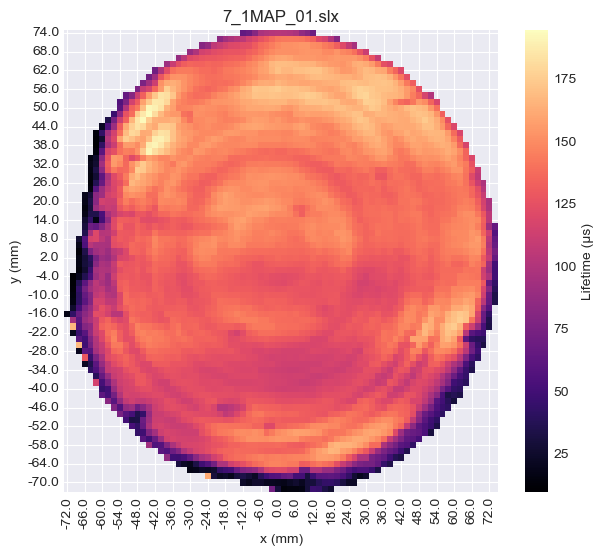

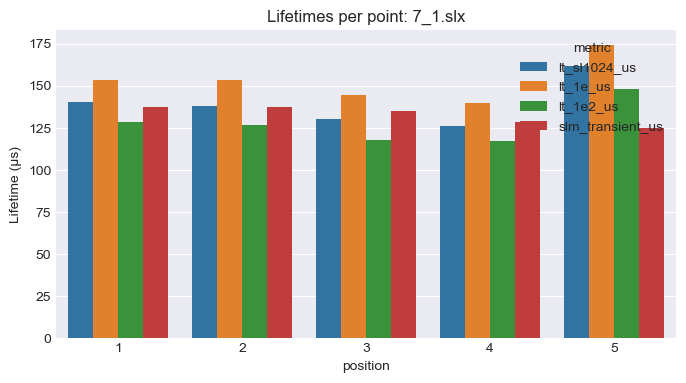

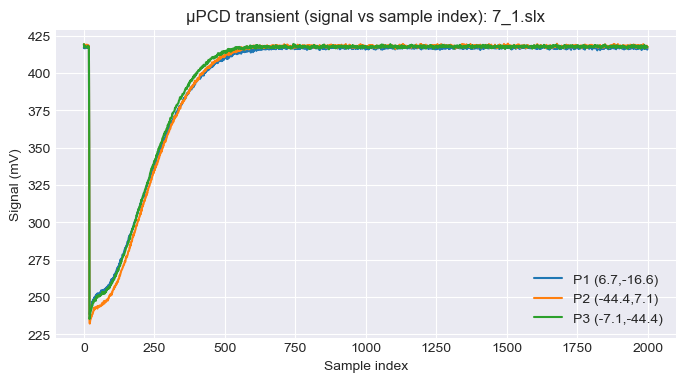

In [22]:
# Demo plots (pick first MAP and first point run)
if map_files:
    plot_map_heatmap(map_files[0], records[map_files[0]])

if point_files:
    compare_point_lifetimes(point_files[0], records[point_files[0]])
    plot_waveforms(point_files[0], records[point_files[0]], max_points=3)



there are 4 methods for the timeconstant. three come from the slx file

LT(Sl/1024):	142.9 us
LT(1/e):	158.09 us
LT(1/e2):	130.23 us

and one from the bmp or slm file

slm_transient_us = 142.01 us

the LT(Sl/1024) and slm_transient_us are very similar, i use the transcient bc that one appears in the photos


i forgot which file corresponds to which measurement so here i am checking the times

In [23]:
# Print filename → time (date), ordered by measurement time
rows = []
for name, rec in records.items():
    dt = rec.get("datetime")
    if dt is not None:
        rows.append((dt, name))
ordered = sorted(rows)
for dt, name in ordered:
    print(f"{name} - {dt.strftime('%H:%M')} ({dt.date()})")


B2_1MAP_01.slx - 13:52 (2025-11-27)
B2_1.slx - 13:53 (2025-11-27)
B2_2.slx - 13:58 (2025-11-27)
B2_3.slx - 14:02 (2025-11-27)
B2_4.slx - 14:06 (2025-11-27)
B2_4MAP_01.slx - 14:10 (2025-11-27)
7_1.slx - 14:30 (2025-11-27)
7_1MAP_01.slx - 14:30 (2025-11-27)
7_2.slx - 14:36 (2025-11-27)
7_3.slx - 14:41 (2025-11-27)
7_4.slx - 14:46 (2025-11-27)
7_4MAP_01.slx - 14:50 (2025-11-27)
B2_1RMAP_01.slx - 14:57 (2025-11-27)
B2_1R.slx - 14:58 (2025-11-27)
B2_2R.slx - 15:08 (2025-11-27)
B2_3R.slx - 15:18 (2025-11-27)
B2_4R.slx - 15:28 (2025-11-27)
B2_5R.slx - 15:38 (2025-11-27)


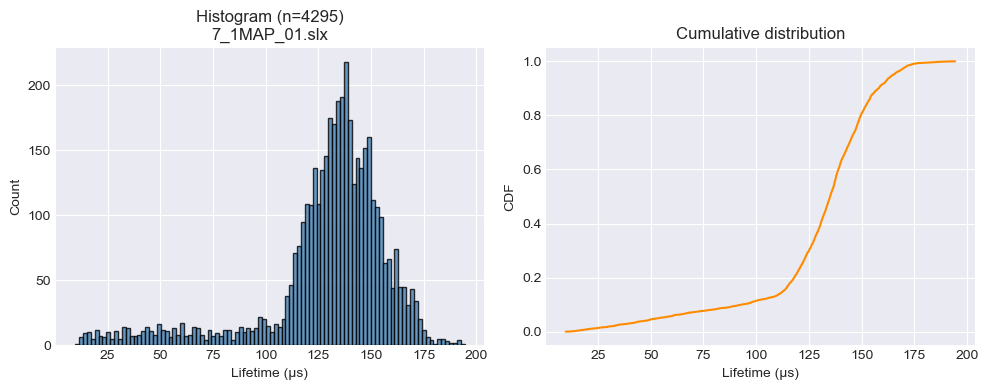

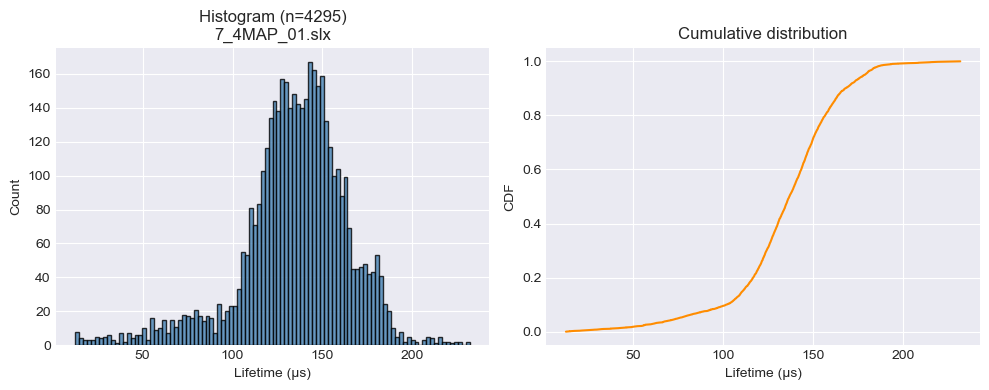

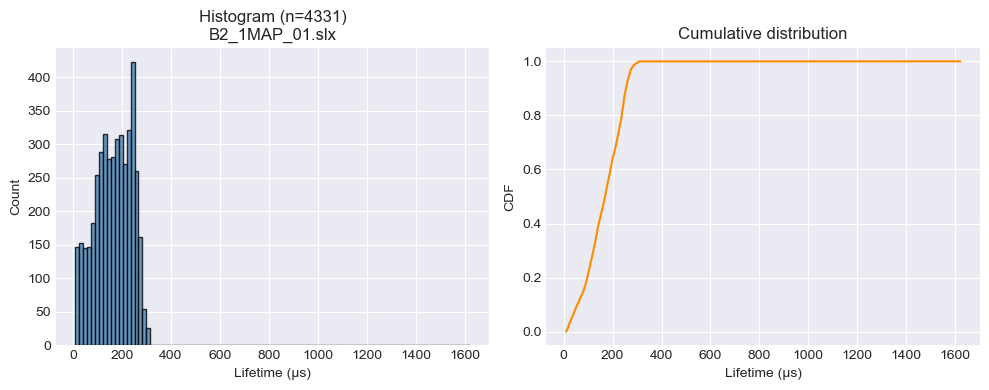

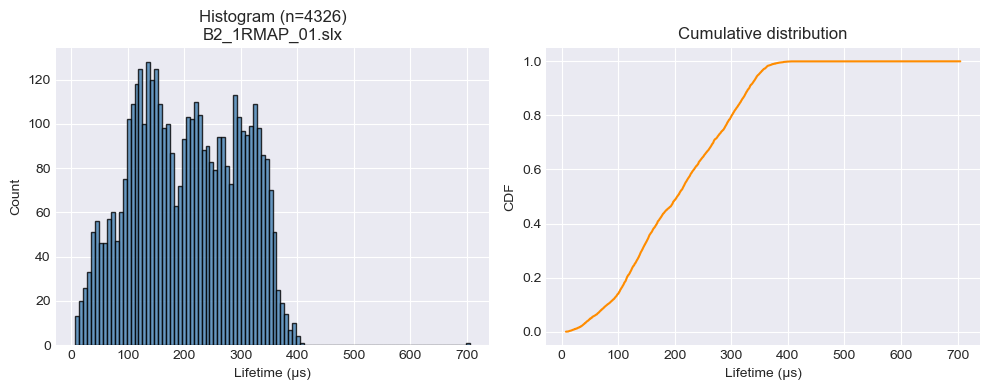

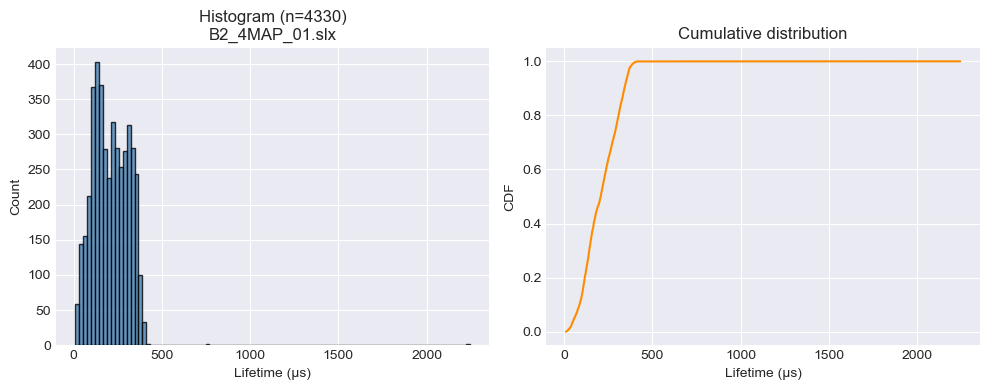

In [24]:
def plot_map_distributions(name, rec, bins=50):
    df = rec["map_points"]
    if df.empty:
        print(f"No map data for {name}")
        return
    vals = df["lifetime_us"].dropna().to_numpy()
    if vals.size == 0:
        print(f"No lifetime values for {name}")
        return
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(vals, bins=bins, color="steelblue", edgecolor="black", alpha=0.8)
    axes[0].set_title(f"Histogram (n={vals.size})\n{name}")
    axes[0].set_xlabel("Lifetime (µs)")
    axes[0].set_ylabel("Count")

    sorted_vals = np.sort(vals)
    cum = np.arange(1, sorted_vals.size + 1) / sorted_vals.size
    axes[1].plot(sorted_vals, cum, color="darkorange")
    axes[1].set_title("Cumulative distribution")
    axes[1].set_xlabel("Lifetime (µs)")
    axes[1].set_ylabel("CDF")
    plt.tight_layout()
    plt.show()


# Run distributions for all MAP files
for name in map_files:
    plot_map_distributions(name, records[name], bins=100)



In [25]:
# Map stats summary: mean/median/min/max and header deviation (%)
for name in map_files:
    rec = records[name]
    df = rec["map_points"]
    if df.empty:
        print(f"{name}: no map data")
        continue
    vals = df["lifetime_us"].dropna()
    print(
        f"{name}: mean={vals.mean():.3f} µs, median={vals.median():.3f} µs, "
        f"min={vals.min():.3f} µs, max={vals.max():.3f} µs, "
        f"deviation_header={rec.get('deviation_us', rec.get('deviation_us', None)) or rec.get('deviation', None)}"
    )



7_1MAP_01.slx: mean=129.181 µs, median=135.080 µs, min=9.644 µs, max=194.360 µs, deviation_header=23.552
7_4MAP_01.slx: mean=134.499 µs, median=136.840 µs, min=12.655 µs, max=231.850 µs, deviation_header=22.286
B2_1MAP_01.slx: mean=164.095 µs, median=169.230 µs, min=9.379 µs, max=1621.000 µs, deviation_header=46.467
B2_1RMAP_01.slx: mean=204.678 µs, median=204.430 µs, min=7.727 µs, max=704.840 µs, deviation_header=45.693
B2_4MAP_01.slx: mean=209.063 µs, median=206.835 µs, min=10.012 µs, max=2243.700 µs, deviation_header=48.244


In [26]:
# Print selected files for quick validation
selected = [
    "B2_1MAP_01.slx",
    
    "B2_1.slx",
    "B2_2.slx",
    "B2_3.slx",
    "B2_4.slx",
    "B2_4MAP_01.slx",
    "7_1.slx",
    "7_1MAP_01.slx",
    "7_2.slx",
    "7_3.slx",
    "7_4.slx",
    "7_4MAP_01.slx",
]

for name in selected:
    rec = records.get(name)
    if rec is None:
        print(f"{name}: not loaded")
        continue
    dt = rec.get("datetime")
    print(f"\n=== {name} @ {dt.strftime('%Y-%m-%d %H:%M') if dt is not None else 'n/a'} ===")
    if rec["type"] == "map":
        df = rec["map_points"]
        vals = df["lifetime_us"].dropna()
        print(f"type=MAP, n={len(vals)}, mean={vals.mean():.3f} µs, median={vals.median():.3f} µs, "
              f"min={vals.min():.3f} µs, max={vals.max():.3f} µs, header_dev={rec.get('deviation_us', rec.get('deviation', None))}")
        print(df.head())
    else:
        df = point_lifetime_df(rec)
        print("type=POINT, per-point lifetimes (µs):")
        display(df[[c for c in df.columns if c != "waveform"]])
        # show slm transient lifetimes if present
        if rec.get("slm_transient_lifetimes_us"):
            print("SLM transient lifetimes (BMP-matching):", rec["slm_transient_lifetimes_us"])




=== B2_1MAP_01.slx @ 2025-11-27 13:52 ===
type=MAP, n=4331, mean=164.095 µs, median=169.230 µs, min=9.379 µs, max=1621.000 µs, header_dev=46.467
   x_mm  y_mm  lifetime_us
0   0.0 -72.0      11.8020
1   2.0 -72.0      24.3760
2   4.0 -72.0       9.8230
3   6.0 -72.0      21.7370
4   8.0 -72.0       9.4621

=== B2_1.slx @ 2025-11-27 13:53 ===
type=POINT, per-point lifetimes (µs):


,position,x_mm,y_mm,lt_sl1024_us,lt_1e_us,lt_1e2_us,slm_transient_us
0,1,16.2,7.6,264.52,244.74,215.64,240.315491
1,2,-4.5,-44.8,165.03,177.13,147.59,240.315491
2,3,44.8,-4.5,220.16,216.84,195.99,159.474609
3,4,4.5,44.8,187.61,194.27,166.98,208.151611
4,5,-44.8,4.5,123.04,134.17,114.41,178.842270


SLM transient lifetimes (BMP-matching): [240.3154907, 240.3154907, 159.4746094, 208.1516113, 178.8422699, 121.9803314]

=== B2_2.slx @ 2025-11-27 13:58 ===
type=POINT, per-point lifetimes (µs):


,position,x_mm,y_mm,lt_sl1024_us,lt_1e_us,lt_1e2_us,slm_transient_us
0,1,16.2,7.6,390.28,287.55,245.34,311.411163
1,2,-4.5,-44.8,189.88,200.68,164.65,311.411163
2,3,44.8,-4.5,370.74,283.71,241.39,179.568008
3,4,4.5,44.8,224.82,220.72,185.86,301.237854
4,5,-44.8,4.5,143.04,154.80,129.36,206.445587


SLM transient lifetimes (BMP-matching): [311.4111633, 311.4111633, 179.5680084, 301.237854, 206.4455872, 140.486496]

=== B2_3.slx @ 2025-11-27 14:02 ===
type=POINT, per-point lifetimes (µs):


...

SLM transient lifetimes (BMP-matching): [141.3480072, 141.3480072, 145.3920593, 130.8170776, 130.0805054, 165.7301025]

=== 7_3.slx @ 2025-11-27 14:41 ===
type=POINT, per-point lifetimes (µs):


,position,x_mm,y_mm,lt_sl1024_us,lt_1e_us,lt_1e2_us,slm_transient_us
0,1,6.7,-16.6,142.90,158.09,130.23,140.111939
1,2,-44.4,7.1,150.53,165.69,135.11,140.111939
2,3,-7.1,-44.4,127.96,144.07,114.47,146.451904
3,4,44.4,-7.1,130.91,144.27,117.58,126.221184
4,5,7.1,44.4,174.59,186.62,157.57,129.177292


SLM transient lifetimes (BMP-matching): [140.1119385, 140.1119385, 146.4519043, 126.2211838, 129.1772919, 168.0809631]

=== 7_4.slx @ 2025-11-27 14:46 ===
type=POINT, per-point lifetimes (µs):


,position,x_mm,y_mm,lt_sl1024_us,lt_1e_us,lt_1e2_us,slm_transient_us
0,1,6.7,-16.6,141.78,155.72,127.54,139.034347
1,2,-44.4,7.1,148.77,164.33,133.84,139.034347
2,3,-7.1,-44.4,122.84,139.55,111.58,145.049042
3,4,44.4,-7.1,125.41,141.30,114.43,121.586357
4,5,7.1,44.4,176.29,188.14,160.00,124.467369


SLM transient lifetimes (BMP-matching): [139.0343475, 139.0343475, 145.0490417, 121.5863571, 124.4673691, 168.4965515]

=== 7_4MAP_01.slx @ 2025-11-27 14:50 ===
type=MAP, n=4295, mean=134.499 µs, median=136.840 µs, min=12.655 µs, max=231.850 µs, header_dev=22.286
   x_mm  y_mm  lifetime_us
0   0.0 -72.0       32.018
1   2.0 -72.0       37.459
2   4.0 -72.0       37.459
3   6.0 -72.0       38.489
4   8.0 -72.0       38.441


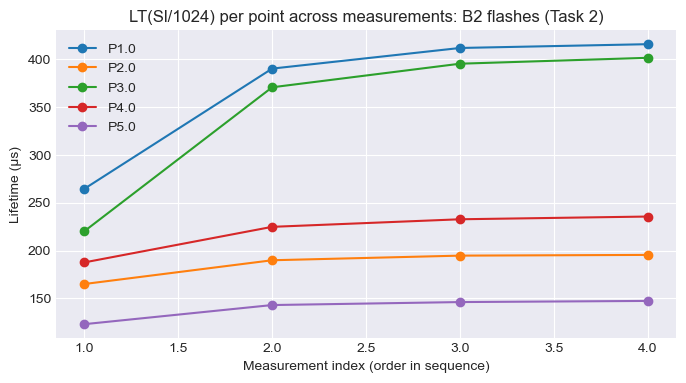

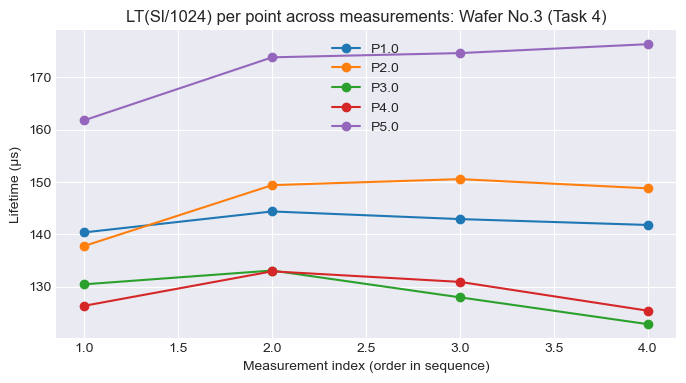

In [27]:
# Point-mode saturation plots (LT(Sl/1024) per position across measurements)

def plot_point_sequence(files, title):
    data = []
    for idx, fname in enumerate(files):
        rec = records.get(fname)
        if not rec or rec["type"] != "point":
            continue
        df = point_lifetime_df(rec)
        for _, row in df.iterrows():
            data.append({
                "measurement": idx + 1,  # order in the provided list
                "file": fname,
                "position": row["position"],
                "lt_sl1024_us": row["lt_sl1024_us"],
            })
    if not data:
        print(f"No point data for {title}")
        return
    seq = pd.DataFrame(data)
    plt.figure(figsize=(8, 4))
    for pos, grp in seq.groupby("position"):
        plt.plot(grp["measurement"], grp["lt_sl1024_us"], marker="o", label=f"P{pos}")
    plt.title(f"LT(Sl/1024) per point across measurements: {title}")
    plt.xlabel("Measurement index (order in sequence)")
    plt.ylabel("Lifetime (µs)")
    plt.legend()
    plt.show()

plot_point_sequence(["B2_1.slx","B2_2.slx","B2_3.slx","B2_4.slx"], "B2 flashes (Task 2)")
plot_point_sequence(["7_1.slx","7_2.slx","7_3.slx","7_4.slx"], "Wafer No.3 (Task 4)")



above: i was expecting to see nice saturations but it's shit. no prob

In [ ]:
# Map-averaged approach: use mean lifetime before/after, then compute C and N_Fe'
N_Fe = 7.36e10  # 1/cm^3

b2_before = records.get("B2_1MAP_01.slx")
b2_after = records.get("B2_4MAP_01.slx")
wafer7_before = records.get("7_1MAP_01.slx")
wafer7_after = records.get("7_4MAP_01.slx")

if b2_before and b2_after:
    tb_mean = b2_before["map_points"]["lifetime_us"].dropna().mean()
    ta_mean = b2_after["map_points"]["lifetime_us"].dropna().mean()
    C_avg = N_Fe / ((1/tb_mean) - (1/ta_mean))
    print(f"B2 maps (mean-based): tau_before={tb_mean:.3f} µs, tau_after={ta_mean:.3f} µs")
    print(f"C_avg = {C_avg:.6e} cm^3·µs")
else:
    C_avg = np.nan
    print("Missing B2 maps for mean-based C calculation")

if wafer7_before and wafer7_after and np.isfinite(C_avg):
    tb7_mean = wafer7_before["map_points"]["lifetime_us"].dropna().mean()
    ta7_mean = wafer7_after["map_points"]["lifetime_us"].dropna().mean()
    N_Fe_prime_mean = C_avg * ((1/tb7_mean) - (1/ta7_mean))
    print(f"\nWafer 7 maps (mean-based): tau_before={tb7_mean:.3f} µs, tau_after={ta7_mean:.3f} µs")
    print(f"N_Fe_prime (mean-based) = {N_Fe_prime_mean:.6e} cm^-3")
else:
    print("Cannot compute mean-based N_Fe' (missing maps or C_avg)")



above: in the lab we did the C and N_Fe using the mean value for tau. first mean tau and then calculate. this is kinda wrong, 

below: first you should calculate C and N_Fe and then do the mean. for this we use the MAP and do it per point, and then mean.

In [28]:
# Per-point C from B2 maps, then N_Fe' for wafer 7 maps
N_Fe = 7.36e10  # 1/cm^3

b2_before = records.get("B2_1MAP_01.slx")
b2_after = records.get("B2_4MAP_01.slx")
wafer7_before = records.get("7_1MAP_01.slx")
wafer7_after = records.get("7_4MAP_01.slx")

if b2_before and b2_after:
    df_b2 = b2_before["map_points"].merge(b2_after["map_points"], on=["x_mm","y_mm"], suffixes=("_before","_after"))
    df_b2["C_cm3_us"] = N_Fe / ((1/df_b2["lifetime_us_before"]) - (1/df_b2["lifetime_us_after"]))
    df_b2 = df_b2.replace([np.inf, -np.inf], np.nan).dropna(subset=["C_cm3_us"])
    C_mean = df_b2["C_cm3_us"].mean()
    print("B2 per-point C stats (cm^3·µs):")
    print(df_b2["C_cm3_us"].describe())
else:
    C_mean = np.nan
    print("Missing B2 map(s) for C calculation")

if wafer7_before and wafer7_after and np.isfinite(C_mean):
    df7 = wafer7_before["map_points"].merge(wafer7_after["map_points"], on=["x_mm","y_mm"], suffixes=("_before","_after"))
    df7["N_Fe_prime_cm3"] = C_mean * ((1/df7["lifetime_us_before"]) - (1/df7["lifetime_us_after"]))
    df7 = df7.replace([np.inf, -np.inf], np.nan).dropna(subset=["N_Fe_prime_cm3"])
    print("\nWafer 7 per-point N_Fe' stats (cm^-3) using C_mean:")
    print(df7["N_Fe_prime_cm3"].describe())
else:
    print("Cannot compute N_Fe' (missing maps or C_mean)")



B2 per-point C stats (cm^3·µs):
count    4.328000e+03
mean     2.840602e+13
std      2.738426e+15
min     -1.792393e+17
25%      4.736105e+13
50%      7.025753e+13
75%      8.737100e+13
max      1.636059e+16
Name: C_cm3_us, dtype: float64

Wafer 7 per-point N_Fe' stats (cm^-3) using C_mean:
count    4.294000e+03
mean     2.405601e+10
std      9.972534e+10
min     -6.683074e+11
25%     -3.479506e+09
50%      7.079192e+09
75%      1.354065e+10
max      1.355535e+12
Name: N_Fe_prime_cm3, dtype: float64


however we got huge std bc outliers

so below we kill outliers and do with mean and median

In [68]:
# C and N_Fe tables with error estimates (SE and bootstrap half-width)
import numpy as np
rng = np.random.default_rng(0)

def se_mean(series):
    return series.std(ddof=1) / np.sqrt(series.count()) if series.count() > 1 else np.nan

def se_median(series):
    mad = (series - series.median()).abs().median()
    return 1.2533 * mad / np.sqrt(series.count()) if series.count() > 1 else np.nan

def boot_ci_halfwidth(series, agg="mean", nboot=10000, alpha=0.05):
    data = series.dropna().to_numpy()
    if data.size == 0:
        return np.nan
    res = rng.choice(data, size=(nboot, data.size), replace=True)
    boots = res.mean(axis=1) if agg == "mean" else np.median(res, axis=1)
    lo = np.percentile(boots, 100*alpha/2)
    hi = np.percentile(boots, 100*(1-alpha/2))
    return (hi - lo) / 2

# Recompute B2 map-based C sets
b2_before = records.get("B2_1MAP_01.slx")
b2_after = records.get("B2_4MAP_01.slx")
if b2_before and b2_after:
    N_Fe_ref = 7.36e10
    df_b2 = b2_before["map_points"].merge(b2_after["map_points"], on=["x_mm","y_mm"], suffixes=('_before','_after'))
    df_b2["C_cm3_us_raw"] = N_Fe_ref / ((1/df_b2["lifetime_us_before"]) - (1/df_b2["lifetime_us_after"]))
    mask = (
        df_b2["lifetime_us_after"] > df_b2["lifetime_us_before"]
    ) & df_b2["lifetime_us_before"].between(20, 1000) & df_b2["lifetime_us_after"].between(20, 1000)
    df_filt = df_b2.loc[mask].copy()
    q1, q99 = df_filt["C_cm3_us_raw"].quantile([0.01, 0.99])
    df_trim = df_filt[df_filt["C_cm3_us_raw"].between(q1, q99)]

    rows = []
    entries = [
        ("raw_mean", df_b2["C_cm3_us_raw"], "mean"),
        ("raw_median", df_b2["C_cm3_us_raw"], "median"),
        ("filt_mean", df_filt["C_cm3_us_raw"], "mean"),
        ("filt_median", df_filt["C_cm3_us_raw"], "median"),
        ("trimmed_mean", df_trim["C_cm3_us_raw"], "mean"),
        ("trimmed_median", df_trim["C_cm3_us_raw"], "median"),
    ]
    for meth, series, agg in entries:
        val = series.mean() if agg == "mean" else series.median()
        se = se_mean(series) if agg == "mean" else se_median(series)
        hw = boot_ci_halfwidth(series, agg=agg)
        rows.append({"method": meth, "value": val, "count": series.count(), "SE": se, "boot_hw": hw})
    C_table = pd.DataFrame(rows)
    display(C_table)

    # N_Fe' table using trimmed median C
    wafer7_before = records.get("7_1MAP_01.slx")
    wafer7_after = records.get("7_4MAP_01.slx")
    if wafer7_before and wafer7_after:
        C_use = df_trim["C_cm3_us_raw"].median()
        df7 = wafer7_before["map_points"].merge(wafer7_after["map_points"], on=["x_mm","y_mm"], suffixes=('_before','_after'))
        df7["N_Fe_prime_raw"] = C_use * ((1/df7["lifetime_us_before"]) - (1/df7["lifetime_us_after"]))
        mask7 = (
            df7["lifetime_us_after"] > df7["lifetime_us_before"]
        ) & df7["lifetime_us_before"].between(20, 1000) & df7["lifetime_us_after"].between(20, 1000)
        df7_filt = df7.loc[mask7].copy()
        q1n, q99n = df7_filt["N_Fe_prime_raw"].quantile([0.01, 0.99])
        df7_trim = df7_filt[df7_filt["N_Fe_prime_raw"].between(q1n, q99n)]

        rowsN = []
        entriesN = [
            ("raw_mean", df7["N_Fe_prime_raw"], "mean"),
            ("raw_median", df7["N_Fe_prime_raw"], "median"),
            ("filt_mean", df7_filt["N_Fe_prime_raw"], "mean"),
            ("filt_median", df7_filt["N_Fe_prime_raw"], "median"),
            ("trimmed_mean", df7_trim["N_Fe_prime_raw"], "mean"),
            ("trimmed_median", df7_trim["N_Fe_prime_raw"], "median"),
        ]
        for meth, series, agg in entriesN:
            val = series.mean() if agg == "mean" else series.median()
            se = se_mean(series) if agg == "mean" else se_median(series)
            hw = boot_ci_halfwidth(series, agg=agg)
            rowsN.append({"method": meth, "value": val, "count": series.count(), "SE": se, "boot_hw": hw})
        N_table = pd.DataFrame(rowsN)
        display(N_table)
    else:
        print("Missing wafer 7 maps; cannot compute N_Fe' table")
else:
    print("Missing B2 maps; cannot compute C/N_Fe tables with errors")



,method,value,count,SE,boot_hw
0,raw_mean,2.840602e+13,4328,4.162530e+13,6.762436e+13
1,raw_median,7.025753e+13,4328,3.631816e+11,9.724196e+11
2,filt_mean,7.649321e+13,4165,4.064835e+12,7.534944e+12
3,filt_median,7.145814e+13,4165,3.451062e+11,9.414412e+11
4,trimmed_mean,6.833728e+13,4081,4.901219e+11,9.575934e+11
5,trimmed_median,7.145814e+13,4081,3.378766e+11,9.544343e+11


,method,value,count,SE,boot_hw
0,raw_mean,6.051527e+10,4294,3.828387e+09,7.492122e+09
1,raw_median,1.780841e+10,4294,3.799657e+08,1.202276e+09
2,filt_mean,8.212931e+10,2906,3.783353e+09,7.452658e+09
3,filt_median,2.812276e+10,2906,2.752516e+08,6.696133e+08
4,trimmed_mean,6.840484e+10,2846,2.723208e+09,5.323969e+09
5,trimmed_median,2.812276e+10,2846,2.701389e+08,6.668192e+08


above: much nicer value for C and N_Fe

here we do the Fe_i(t) and FeB(t) curves based on the Task 1 (before flash) measurement and the 10m separated measurements

we also recalculate C and we get the same value as previously although this was unnecessary

Using C = 7.145814e+13 cm^3·µs (trimmed median from B2 maps)


,time_min,Fe_i_mean_cm3,Fe_i_median_cm3,FeB_mean_cm3,FeB_median_cm3
0,0,8.612982e+10,8.256881e+10,NaN,NaN
1,10,8.395981e+10,7.968921e+10,2.905438e+09,3.107236e+09
2,20,8.232813e+10,7.850938e+10,4.822082e+09,3.934962e+09
3,30,7.891018e+10,7.492853e+10,7.219644e+09,7.095378e+09
4,40,7.806222e+10,7.312004e+10,8.067600e+09,8.892839e+09


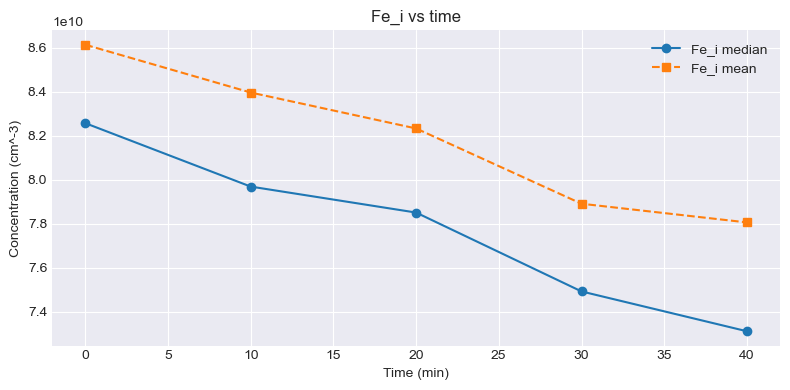

In [69]:
# Fe_i(t) and FeB(t) vs time using per-point B2 R-series (5-point SLX)
# Model: Fe_total per point from pre-flash (paired) and immediate post-flash (t0) lifetimes
# Fe_i(t)   = C * (1/τ_pair - 1/τ_t)
# Fe_total  = C * (1/τ_pair - 1/τ_t0)
# FeB(t)    = Fe_total - Fe_i(t)
# Times: assume 10 min spacing between R steps; t0 = B2_1R

# Choose iron constant C: use robust trimmed median from earlier step
# (Recompute here to keep cell standalone.)
N_Fe_ref = 7.36e10  # known Fe for constant extraction (not used directly below)
C_use = None

# Recompute C_use (trimmed median) from B2_1MAP_01 -> B2_4MAP_01 maps, consistent with prior robust calc
b2_before_map = records.get("B2_1MAP_01.slx")
b2_after_map = records.get("B2_4MAP_01.slx")
if b2_before_map and b2_after_map:
    df_b2c = b2_before_map["map_points"].merge(b2_after_map["map_points"], on=["x_mm","y_mm"], suffixes=('_before','_after'))
    df_b2c["C_cm3_us_raw"] = N_Fe_ref / ((1/df_b2c["lifetime_us_before"]) - (1/df_b2c["lifetime_us_after"]))
    maskC = (
        df_b2c["lifetime_us_after"] > df_b2c["lifetime_us_before"]
    ) & df_b2c["lifetime_us_before"].between(20, 1000) & df_b2c["lifetime_us_after"].between(20, 1000)
    dfC_filt = df_b2c.loc[maskC].copy()
    q1c, q99c = dfC_filt["C_cm3_us_raw"].quantile([0.01, 0.99])
    dfC_trim = dfC_filt[dfC_filt["C_cm3_us_raw"].between(q1c, q99c)]
    C_use = dfC_trim["C_cm3_us_raw"].median()
else:
    C_use = None

if C_use is None:
    print("Cannot proceed: C_use not available")
else:
    print(f"Using C = {C_use:.6e} cm^3·µs (trimmed median from B2 maps)")

    # Load paired (before flash) and post-flash R series (5-point SLX)
    paired = records.get("B2_1.slx")  # pre-flash
    t0 = records.get("B2_1R.slx")     # immediately post-flash
    r_series = [
        ("t0", t0),
        ("t10", records.get("B2_2R.slx")),
        ("t20", records.get("B2_3R.slx")),
        ("t30", records.get("B2_4R.slx")),
        ("t40", records.get("B2_5R.slx")),
    ]
    if paired is None or t0 is None:
        print("Missing B2_1 or B2_1R point files")
    else:
        # Extract per-point LT(Sl/1024) for consistent positions (1..5)
        def point_lts(rec):
            df = point_lifetime_df(rec)
            return df.set_index("position")["lt_sl1024_us"]

        tau_pair = point_lts(paired)
        tau_t0 = point_lts(t0)

        # Compute Fe_total per point
        Fe_total = C_use * ((1 / tau_pair) - (1 / tau_t0))

        times_min = []
        Fe_i_means = []
        Fe_i_meds = []
        FeB_means = []
        FeB_meds = []

        for idx, (label, rec) in enumerate(r_series):
            if rec is None:
                continue
            tau_t = point_lts(rec)
            # align indices
            common = tau_pair.index.intersection(tau_t.index)
            Fe_i = C_use * ((1 / tau_pair[common]) - (1 / tau_t[common]))
            FeB = Fe_total[common] - Fe_i
            # drop negatives
            Fe_i = Fe_i[Fe_i > 0]
            FeB = FeB[FeB > 0]
            if len(Fe_i) == 0:
                continue
            t_minutes = idx * 10  # t0=0, then 10 min steps
            times_min.append(t_minutes)
            Fe_i_means.append(Fe_i.mean())
            Fe_i_meds.append(Fe_i.median())
            FeB_means.append(FeB.mean())
            FeB_meds.append(FeB.median())

        Fe_df = pd.DataFrame({
            "time_min": times_min,
            "Fe_i_mean_cm3": Fe_i_means,
            "Fe_i_median_cm3": Fe_i_meds,
            "FeB_mean_cm3": FeB_means,
            "FeB_median_cm3": FeB_meds,
        })
        display(Fe_df)

        # Plot Fe_i and FeB over time (median and mean)
        plt.figure(figsize=(8,4))
        plt.plot(Fe_df["time_min"], Fe_df["Fe_i_median_cm3"], marker="o", label="Fe_i median")
        plt.plot(Fe_df["time_min"], Fe_df["Fe_i_mean_cm3"], marker="s", linestyle="--", label="Fe_i mean")
        # plt.plot(Fe_df["time_min"], Fe_df["FeB_median_cm3"], marker="o", label="FeB median")
        # plt.plot(Fe_df["time_min"], Fe_df["FeB_mean_cm3"], marker="s", linestyle="--", label="FeB mean")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration (cm^-3)")
        plt.title("Fe_i vs time")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # # Plot Fe_i and FeB over time (median and mean)
        # plt.figure(figsize=(8,4))
        # plt.plot(Fe_df["time_min"], Fe_df["Fe_i_median_cm3"], marker="o", label="Fe_i median")
        # plt.plot(Fe_df["time_min"], Fe_df["Fe_i_mean_cm3"], marker="s", linestyle="--", label="Fe_i mean")
        # plt.plot(Fe_df["time_min"], Fe_df["FeB_median_cm3"], marker="o", label="FeB median")
        # plt.plot(Fe_df["time_min"], Fe_df["FeB_mean_cm3"], marker="s", linestyle="--", label="FeB mean")
        # plt.xlabel("Time (min)")
        # plt.ylabel("Concentration (cm^-3)")
        # plt.title("Fe_i and FeB vs time (B2 R-series, 5-point)")
        # plt.legend()
        # plt.tight_layout()
        # plt.show()

I need the N_B boron concentration (or the resistivity, which could be used to estimate the N_B) but we dont have it. so we will calculate D0 for a couple possible values of N_B 

In [59]:
# D0 table vs plausible NB values using fitted R from Fe_i decay (median-based)
# Assumes you already ran the previous cell so Fe_df exists.
import math
if 'Fe_df' not in globals() or Fe_df.empty:
    print("Run the Fe_i/FeB cell first to get Fe_df and the fitted R.")
else:
    # Fit R using Fe_i_median (more robust), ignoring the first point if desired
    t = Fe_df['time_min'].to_numpy()
    Fe_i_med = Fe_df['Fe_i_median_cm3'].to_numpy()
    # Keep only positive
    mask_pos = Fe_i_med > 0
    t = t[mask_pos]
    Fe_i_med = Fe_i_med[mask_pos]
    if len(t) < 3:
        print("Not enough positive points to fit R")
    else:
        # Fit ln(Fe_i) vs t: ln(Fe_i) = ln(Fe0) - R * t
        # Convert time to seconds or keep minutes; we'll keep minutes then convert
        coeffs = np.polyfit(t, np.log(Fe_i_med), 1)
        slope = coeffs[0]
        R_per_min = -slope
        R_per_s = R_per_min / 60.0
        print(f"Fitted R: {R_per_min:.3e} 1/min  ({R_per_s:.3e} 1/s)")

        # R² of the log-linear fit
        y = np.log(Fe_i_med)
        y_pred = np.polyval(coeffs, t)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
        print(f"R^2 (log-fit): {r2:.4f}")

        # Constants
        T_K = 300.0
        E_mig_eV = 0.64
        eps_r = 11.7
        e = 1.602176634e-19
        eps0 = 8.8541878128e-12
        kB = 1.380649e-23

        def compute_D0(R_s, NB_cm3):
            NB_m3 = NB_cm3 * 1e6
            pref = (eps_r * eps0 * kB * T_K) / (e**2 * NB_m3)
            return R_s * pref * math.exp(E_mig_eV * e / (kB * T_K))

        NB_values = [1e15, 3e15, 1e16, 3e16, 1e17]  # cm^-3
        rows = []
        for NB in NB_values:
            D0 = compute_D0(R_per_s, NB)
            # rows.append({"NB_cm^-3": NB, "D0_m2_per_s": D0})
            rows.append({"NB_cm^-3": NB, "D0_cm2_per_s": D0*1e4})
            # print(f"NB={NB:.2e} cm^-3  D0={D0*1e4:.3e} cm^2/s")
        D0_table = pd.DataFrame(rows)
        display(D0_table)



Fitted R: 3.047e-03 1/min  (5.078e-05 1/s)
R^2 (log-fit): 0.9822


,NB_cm^-3,D0_cm2_per_s
0,1.000000e+15,0.000479
1,3.000000e+15,0.000160
2,1.000000e+16,0.000048
3,3.000000e+16,0.000016
4,1.000000e+17,0.000005


these are kinda super high for D0

In [67]:
kB = 8.61733326e-5
T_K = 300.0
DF=9.5e-4 * np.exp(-0.65/(kB*T_K)) # japan
# DF=3.3 * 10e-1 * np.exp(-0.81/kB*T_K) # 1988
print(DF)


1.143415831338209e-14


In [62]:
import numpy as np

# Constants
k_B = 8.617333262145e-5  # eV/K, Boltzmann constant

# Models: (D0, Ea [eV], label)
models = [
    (9.5e-4, 0.65, "High-T fit (Isobe/Nakashima 1989)"),
    (3.3e-1, 0.81, "Low-T fit (Nakashima/Isobe 1988)")
]

def D_of_T(D0, Ea, T):
    return D0 * np.exp(-Ea / (k_B * T))

Ts = np.linspace(200, 400, 201)  # from 200 K to 400 K
for D0, Ea, label in models:
    Ds = D_of_T(D0, Ea, Ts)
    print(f"Model: {label}")
    # print(" T (K) | D (cm^2/s)")
    # for T, D in zip(Ts[::50], Ds[::50]):  # print every 50th point
        # print(f" {T:6.1f} | {D:.3e}")
    print("  ... at 300 K:", D_of_T(D0, Ea, 300), "\n")


Model: High-T fit (Isobe/Nakashima 1989)
  ... at 300 K: 1.1434158384943333e-14 

Model: Low-T fit (Nakashima/Isobe 1988)
  ... at 300 K: 8.149159900147657e-15 

